In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
column_names = ['train_data_size', 'val_data_size', 'random_seed', 'representation', 
                'train_accuracy', 'val_accuracy', 'test_accuracy', 'num_epochs', 'batch_size']

In [5]:
df = pd.read_csv('../results/dvs128_cnn_01_to_09_batch16_3seeds.txt', names=column_names, skiprows=1)

In [6]:
df.head()

,train_data_size,val_data_size,random_seed,representation,train_accuracy,val_accuracy,test_accuracy,num_epochs,batch_size
0,0.1,0.1,13,binary,0.648148,0.429435,0.526515,9,16
1,0.1,0.1,13,n_bins,0.660185,0.400662,0.481061,11,16
2,0.1,0.1,13,spike_count,0.563889,0.445804,0.571970,11,16
3,0.1,0.1,13,timesurface,0.600000,0.438811,0.545455,11,16
4,0.1,0.1,13,time_window,0.631481,0.459790,0.568182,11,16


In [7]:
grouped_data = df.groupby(['train_data_size', 'representation']).agg({
    'train_accuracy': 'mean',
    'val_accuracy': 'mean',
    'test_accuracy': 'mean'
}).reset_index()

In [8]:
grouped_data.head()

,train_data_size,representation,train_accuracy,val_accuracy,test_accuracy
0,0.1,binary,0.665509,0.445995,0.547980
1,0.1,n_bins,0.677701,0.414428,0.476010
2,0.1,spike_count,0.628164,0.467525,0.546717
3,0.1,time_window,0.669213,0.481432,0.569444
4,0.1,timesurface,0.636728,0.480753,0.556818


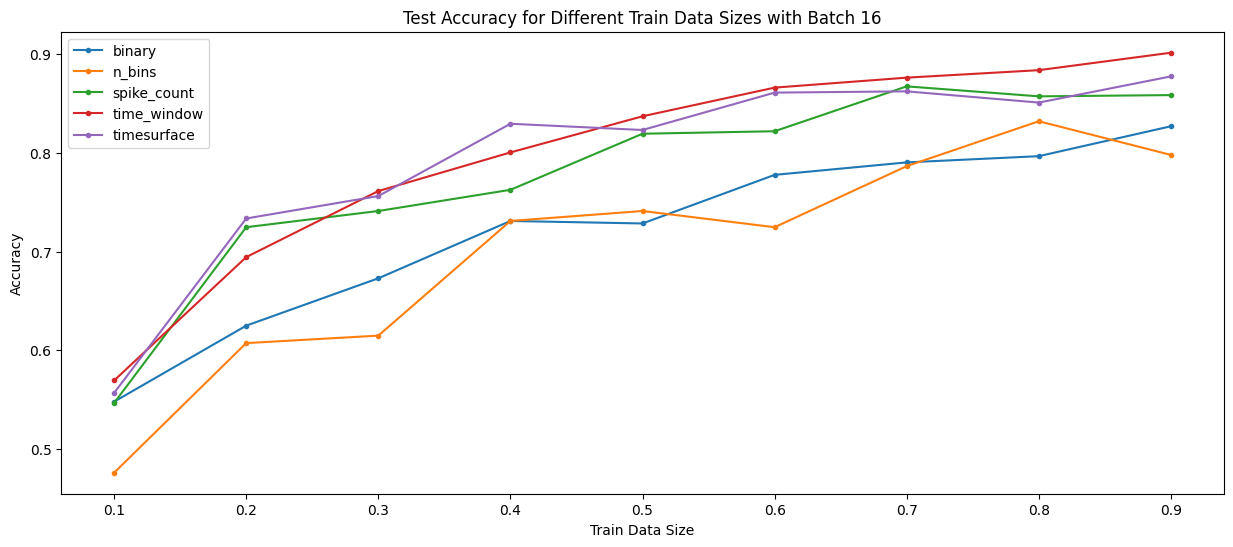

In [10]:
fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_data_size'], rep_data['test_accuracy'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Accuracy')
plt.title('Test Accuracy for Different Train Data Sizes with Batch 16')
plt.legend()
plt.show()

In [11]:
df2 = pd.read_csv('../results/dvs128_cnn_09_batch16_10seeds.txt')

In [12]:
df2.head()

,train_data_size,val_data_size,random_seed,representation,train_acc,val_acc,test_acc,num_epochs,batch_size
0,0.9,0.1,13,binary,0.860412,0.739566,0.814394,11,16
1,0.9,0.1,13,n_bins,0.884433,0.747913,0.738636,11,16
2,0.9,0.1,13,spike_count,0.948247,0.890200,0.840909,21,16
3,0.9,0.1,13,timesurface,0.897938,0.850148,0.878788,13,16
4,0.9,0.1,13,time_window,0.912887,0.867953,0.890152,13,16


In [19]:
df2['num_epochs'] = df2['num_epochs'] + 1

grouped_data2 = df2.groupby(['representation']).agg({
    'train_acc': ['mean', 'std'],
    'val_acc': ['mean', 'std'],
    'test_acc': ['mean', 'std'],
    'num_epochs': 'mean',
}).reset_index()

In [20]:
grouped_data2.head()

representation train_acc             val_acc            test_acc            \
                      mean       std      mean       std      mean       std   
0         binary  0.874346  0.029888  0.763455  0.035664  0.815236  0.029812   
1         n_bins  0.870516  0.040212  0.734069  0.054502  0.789141  0.041451   
2    spike_count  0.900477  0.025050  0.857465  0.020536  0.864057  0.030973   
3    time_window  0.901445  0.023152  0.863873  0.035666  0.885943  0.022365   
4    timesurface  0.885845  0.029672  0.840609  0.032720  0.873737  0.016402   

  num_epochs  
        mean  
0  14.222222  
1  12.444444  
2  12.888889  
3  13.333333  
4  13.111111

C:\Users\osvat\AppData\Local\Temp\ipykernel_19168\3578040532.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\osvat\AppData\Local\Temp\ipykernel_19168\3578040532.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


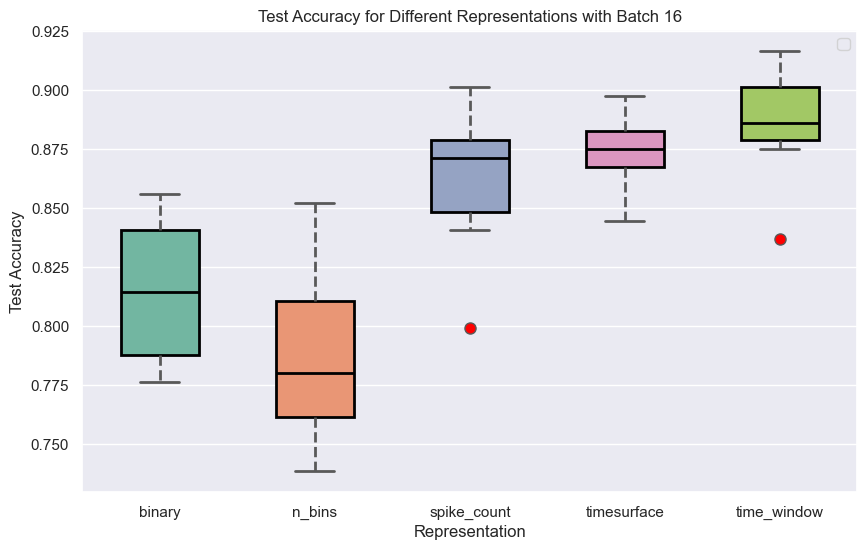

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df2, 
    x="representation", 
    y="test_acc",
    palette="Set2",  # Different colors for each box
    width=0.5,       # Adjust box width
    linewidth=2,     # Border thickness
    flierprops={
        "marker": "o",          # Use points for outliers
        "markerfacecolor": "red",  # Outlier color
        "markersize": 8,        # Outlier size
    },
    whiskerprops={"linestyle": "--"},  # Dashed whiskers
    boxprops={"edgecolor": "black"},  # Box border color
    medianprops={"color": "black"},   # Median line color
)

ax.set_xlabel('Representation')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy for Different Representations with Batch 16')
ax.legend()

In [18]:
grouped_data2 = grouped_data2.round(2)
grouped_data2.to_csv('./dvs128_cnn_09_batch16_10seeds_grouped.csv', index=False)